In [1]:
# Agar model Drive mein hai toh, pehle ye run karo
from google.colab import drive
drive.mount('/content/drive')
!cp -r /content/drive/MyDrive/bert_news_final /content/

Mounted at /content/drive


In [2]:
# Cell 1: Install libraries and imports
!pip install torch torchvision scikit-learn pandas numpy matplotlib seaborn Pillow -q

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Setup
torch.manual_seed(42)
np.random.seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Using device: {DEVICE}')
print(f'✅ PyTorch version: {torch.__version__}')

✅ Using device: cuda
✅ PyTorch version: 2.10.0+cu128


📊 Loading Ames Housing dataset...
✅ Dataset shape: (1460, 9)
📋 Features: ['GrLivArea', 'OverallQual', 'YearBuilt', 'TotalBsmtSF', 'GarageArea', 'BedroomAbvGr', 'FullBath', 'LotArea']
💰 Price range: $34,900 - $755,000


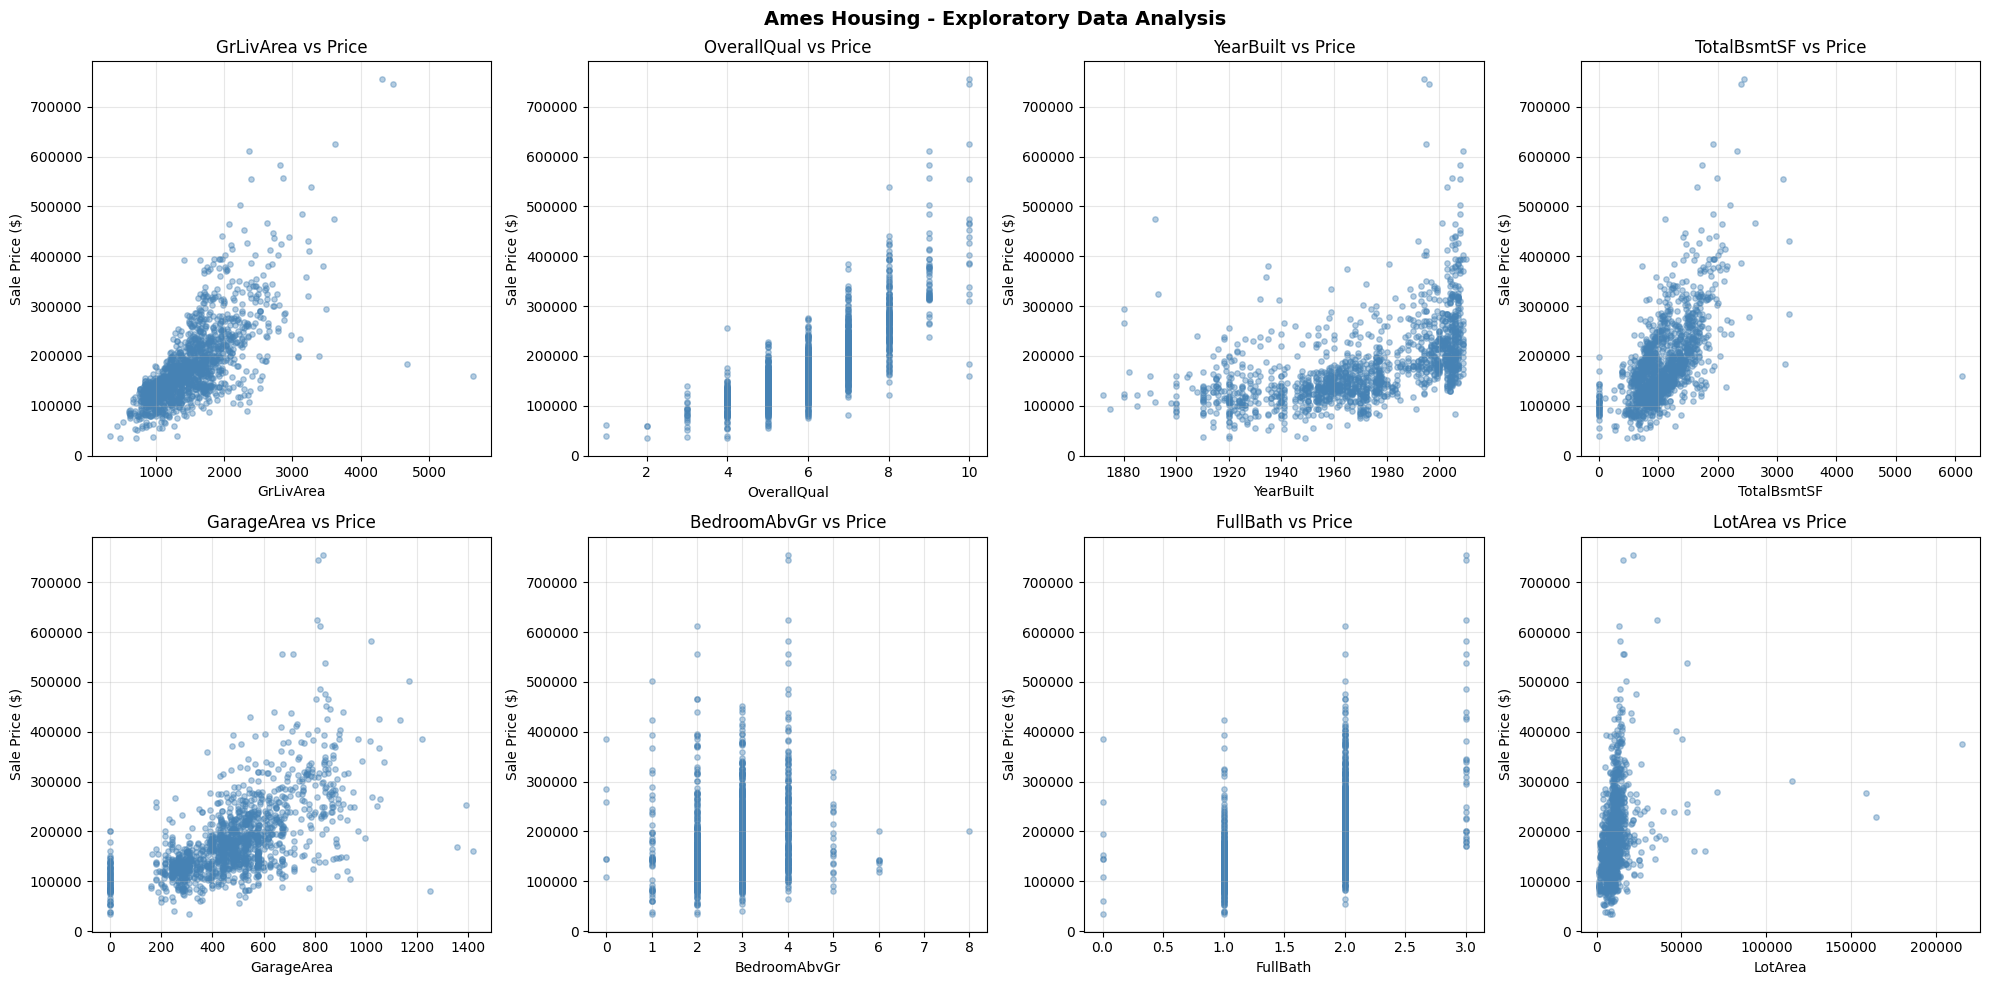

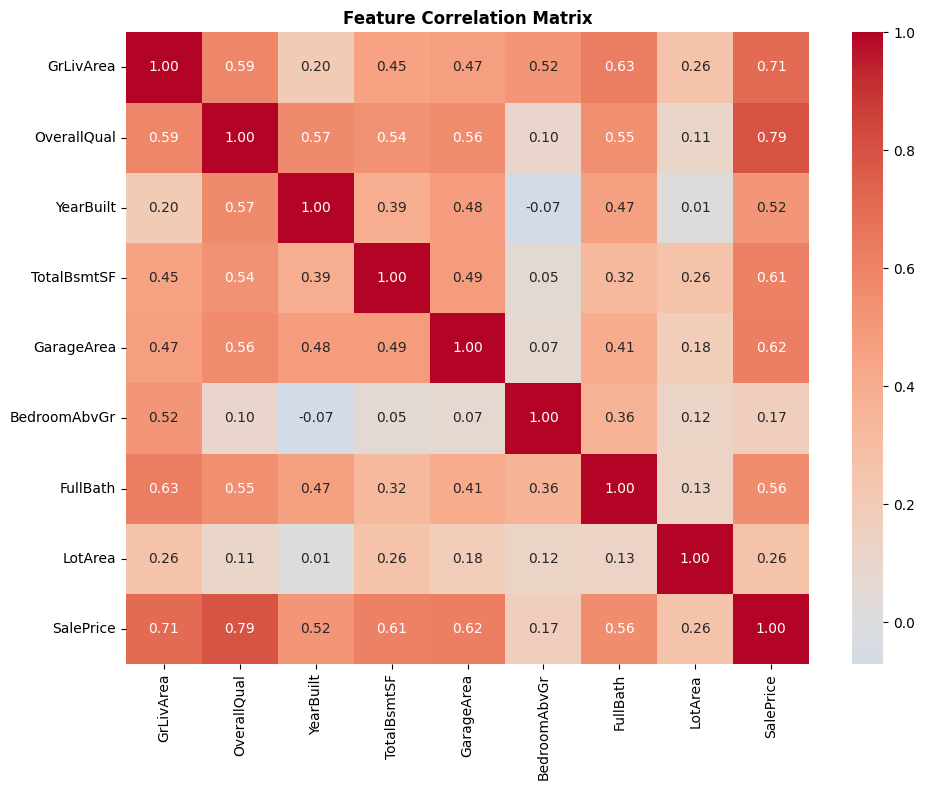


📈 Target distribution skew: 1.88
💰 Price distribution will be log-transformed for better modeling


In [3]:
# Cell 2: Load Ames Housing dataset and perform EDA
from sklearn.datasets import fetch_openml

print("📊 Loading Ames Housing dataset...")
ames = fetch_openml(name='house_prices', as_frame=True, parser='auto')
df = ames.frame.copy()

# Target
TARGET = 'SalePrice'

# Select key numeric features
TABULAR_FEATURES = [
    'GrLivArea', 'OverallQual', 'YearBuilt', 'TotalBsmtSF',
    'GarageArea', 'BedroomAbvGr', 'FullBath', 'LotArea'
]

# Clean data
df = df[TABULAR_FEATURES + [TARGET]].dropna()
df[TABULAR_FEATURES] = df[TABULAR_FEATURES].astype(float)
df[TARGET] = df[TARGET].astype(float)

print(f"✅ Dataset shape: {df.shape}")
print(f"📋 Features: {TABULAR_FEATURES}")
print(f"💰 Price range: ${df[TARGET].min():,.0f} - ${df[TARGET].max():,.0f}")

# EDA Visualization
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Ames Housing - Exploratory Data Analysis', fontsize=14, fontweight='bold')

for idx, feature in enumerate(TABULAR_FEATURES):
    row, col = idx // 4, idx % 4
    axes[row, col].scatter(df[feature], df[TARGET], alpha=0.4, s=15, color='steelblue')
    axes[row, col].set_xlabel(feature)
    axes[row, col].set_ylabel('Sale Price ($)')
    axes[row, col].set_title(f'{feature} vs Price')
    axes[row, col].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(10, 8))
correlation = df[TABULAR_FEATURES + [TARGET]].corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n📈 Target distribution skew: {df[TARGET].skew():.2f}")
print("💰 Price distribution will be log-transformed for better modeling")

In [4]:
# Cell 3: Generate synthetic house images and create dataset class
os.makedirs('house_images', exist_ok=True)

def generate_house_image(idx, quality, price):
    """Generate synthetic house image based on quality score"""
    img_array = np.zeros((224, 224, 3), dtype=np.uint8)

    # Color intensity based on quality (1-10)
    intensity = int(50 + (quality / 10) * 150)
    r = min(255, intensity + np.random.randint(-30, 30))
    g = min(255, intensity - 20 + np.random.randint(-30, 30))
    b = min(255, intensity - 40 + np.random.randint(-30, 30))

    img_array[:, :] = [r, g, b]

    # Add texture
    texture = np.random.randint(-40, 40, (224, 224, 3))
    img_array = np.clip(img_array + texture, 0, 255).astype(np.uint8)

    # Add simple house shape for better visualization
    center_y, center_x = 112, 112
    cv2_exists = False
    try:
        import cv2
        cv2_exists = True
        # Draw rectangle for house
        cv2.rectangle(img_array, (center_x-40, center_y-20), (center_x+40, center_y+40), (200,200,200), -1)
        # Draw roof
        pts = np.array([[center_x-50, center_y-20], [center_x, center_y-60], [center_x+50, center_y-20]], np.int32)
        cv2.fillPoly(img_array, [pts], (150,100,50))
    except:
        pass

    img = Image.fromarray(img_array)
    img.save(f'house_images/img_{idx:04d}.jpg')

print("🏠 Generating synthetic house images...")
for idx, row in df.reset_index(drop=True).iterrows():
    generate_house_image(idx, int(row['OverallQual']), row[TARGET])

print(f"✅ Generated {len(df)} synthetic images in 'house_images/' folder")

# Train-test split
df = df.reset_index(drop=True)
df['image_path'] = [f'house_images/img_{i:04d}.jpg' for i in range(len(df))]

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# Normalize tabular features
scaler = StandardScaler()
X_train_tab = scaler.fit_transform(train_df[TABULAR_FEATURES])
X_test_tab = scaler.transform(test_df[TABULAR_FEATURES])

# Log transform target (house prices are skewed)
y_train = np.log1p(train_df[TARGET].values)
y_test = np.log1p(test_df[TARGET].values)

print(f"✅ Train samples: {len(train_df)}")
print(f"✅ Test samples: {len(test_df)}")
print(f"✅ Feature dimension: {len(TABULAR_FEATURES)}")

# Image transforms
IMG_TRANSFORM = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

class HousingDataset(Dataset):
    def __init__(self, image_paths, tabular_features, targets, transform=None):
        self.image_paths = image_paths
        self.tabular = torch.FloatTensor(tabular_features)
        self.targets = torch.FloatTensor(targets)
        self.transform = transform

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.tabular[idx], self.targets[idx]

train_dataset = HousingDataset(train_df['image_path'].tolist(), X_train_tab, y_train, IMG_TRANSFORM)
test_dataset = HousingDataset(test_df['image_path'].tolist(), X_test_tab, y_test, IMG_TRANSFORM)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

print(f"✅ Train batches: {len(train_loader)}")
print(f"✅ Test batches: {len(test_loader)}")

🏠 Generating synthetic house images...
✅ Generated 1460 synthetic images in 'house_images/' folder
✅ Train samples: 1168
✅ Test samples: 292
✅ Feature dimension: 8
✅ Train batches: 37
✅ Test batches: 10


In [5]:
# Cell 4: Build multimodal model and train
class MultimodalHousingModel(nn.Module):
    """Fusion model combining image (ResNet) and tabular features"""
    def __init__(self, tabular_dim, image_embed_dim=256, tab_embed_dim=128):
        super().__init__()

        # Image branch (ResNet-18)
        resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

        # Freeze early layers, fine-tune later
        for param in list(resnet.parameters())[:-20]:
            param.requires_grad = False

        in_features = resnet.fc.in_features
        resnet.fc = nn.Sequential(
            nn.Linear(in_features, image_embed_dim),
            nn.ReLU(),
            nn.Dropout(0.3)
        )
        self.image_branch = resnet

        # Tabular branch
        self.tab_branch = nn.Sequential(
            nn.Linear(tabular_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, tab_embed_dim),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        # Fusion head
        fusion_dim = image_embed_dim + tab_embed_dim
        self.fusion = nn.Sequential(
            nn.Linear(fusion_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, images, tabular):
        img_feat = self.image_branch(images)
        tab_feat = self.tab_branch(tabular)
        combined = torch.cat([img_feat, tab_feat], dim=1)
        return self.fusion(combined).squeeze(1)

# Initialize model
model = MultimodalHousingModel(tabular_dim=len(TABULAR_FEATURES)).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"📊 Model Architecture:")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")

# Training setup
criterion = nn.HuberLoss(delta=1.0)  # Robust to outliers
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

NUM_EPOCHS = 25
train_losses, val_losses = [], []
best_val_loss = float('inf')

print("\n🚀 Starting training...")
print("="*50)

for epoch in range(1, NUM_EPOCHS + 1):
    # Training
    model.train()
    epoch_loss = 0
    for imgs, tabs, targets in train_loader:
        imgs, tabs, targets = imgs.to(DEVICE), tabs.to(DEVICE), targets.to(DEVICE)

        optimizer.zero_grad()
        preds = model(imgs, tabs)
        loss = criterion(preds, targets)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        epoch_loss += loss.item()

    avg_train_loss = epoch_loss / len(train_loader)

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for imgs, tabs, targets in test_loader:
            imgs, tabs, targets = imgs.to(DEVICE), tabs.to(DEVICE), targets.to(DEVICE)
            preds = model(imgs, tabs)
            val_loss += criterion(preds, targets).item()

    avg_val_loss = val_loss / len(test_loader)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    scheduler.step(avg_val_loss)

    # Save best model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), 'best_multimodal_model.pth')

    # Print progress
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{NUM_EPOCHS} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

print("="*50)
print(f"✅ Training complete! Best validation loss: {best_val_loss:.4f}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 86.2MB/s]


📊 Model Architecture:
  Total parameters: 11,376,385
  Trainable parameters: 9,183,937

🚀 Starting training...
Epoch   1/25 | Train Loss: 11.0632 | Val Loss: 10.3241
Epoch   5/25 | Train Loss: 0.6240 | Val Loss: 0.1525
Epoch  10/25 | Train Loss: 0.4603 | Val Loss: 0.1093
Epoch  15/25 | Train Loss: 0.4792 | Val Loss: 0.1809
Epoch  20/25 | Train Loss: 0.3981 | Val Loss: 0.2675
Epoch  25/25 | Train Loss: 0.4426 | Val Loss: 0.2249
✅ Training complete! Best validation loss: 0.0557



📊 MODEL EVALUATION RESULTS
✅ Mean Absolute Error (MAE):  $42,495
✅ Root Mean Square Error:     $63,573
✅ R² Score:                   0.473
✅ Mean Absolute % Error:      23.05%


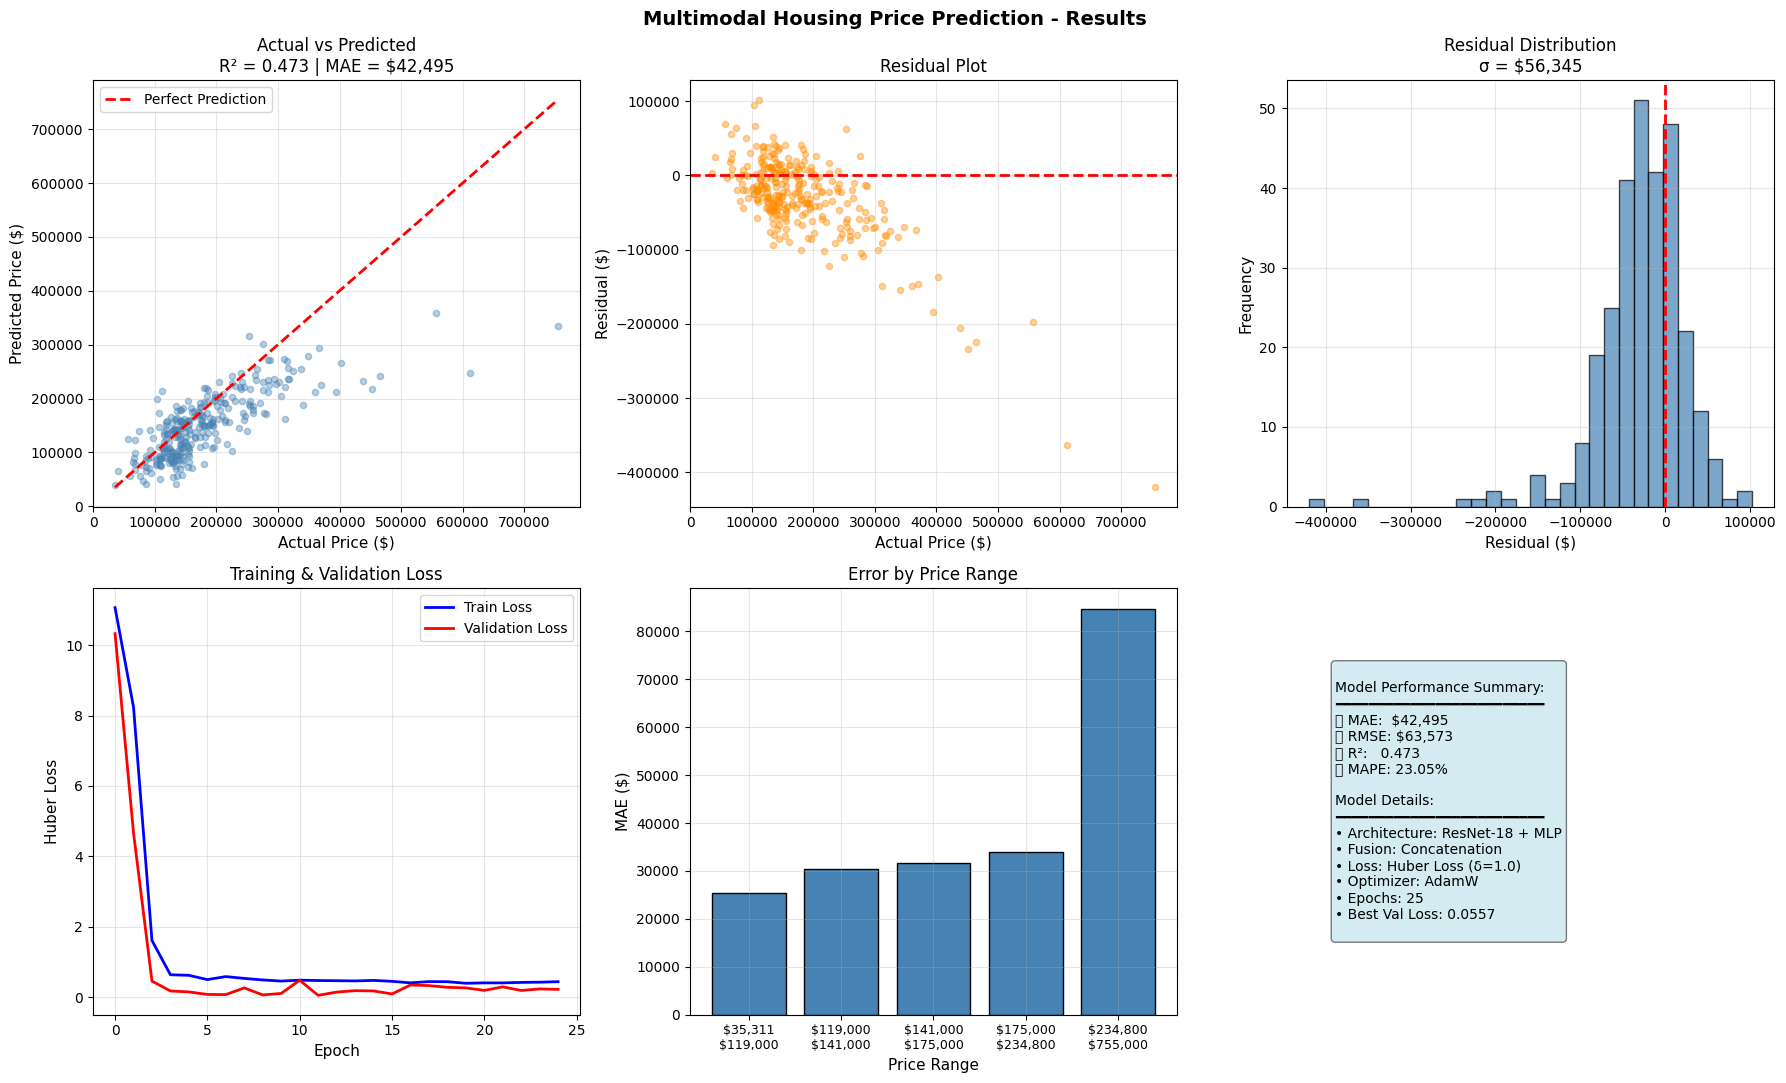


📋 SAMPLE PREDICTIONS (First 10 test samples)
 Actual Price  Predicted Price     Error  Error %
     154500.0          97002.0  -57498.0    -37.0
     325000.0         250717.0  -74283.0    -23.0
     115000.0         101247.0  -13753.0    -12.0
     159000.0         182429.0   23430.0     15.0
     315500.0         256380.0  -59120.0    -19.0
      75500.0          55522.0  -19978.0    -26.0
     311500.0         162802.0 -148698.0    -48.0
     146000.0         149215.0    3215.0      2.0
      84500.0          84795.0     295.0      0.0
     135500.0         177698.0   42198.0     31.0

💾 Complete model saved as 'multimodal_housing_model_complete.pth'

✅ PROJECT 3 COMPLETED SUCCESSFULLY!
🎯 Best R² Score: 0.473
💰 Best MAE: $42,495
🚀 Multimodal model (Images + Tabular) ready for inference!


In [6]:
# Cell 5: Evaluate model and display results
# Load best model
model.load_state_dict(torch.load('best_multimodal_model.pth', map_location=DEVICE))
model.eval()

# Predictions
all_preds, all_true = [], []
with torch.no_grad():
    for imgs, tabs, targets in test_loader:
        imgs, tabs = imgs.to(DEVICE), tabs.to(DEVICE)
        preds = model(imgs, tabs).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(targets.numpy())

# Inverse log transform
y_pred_orig = np.expm1(np.array(all_preds))
y_true_orig = np.expm1(np.array(all_true))

# Metrics
mae = mean_absolute_error(y_true_orig, y_pred_orig)
rmse = np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))
r2 = r2_score(y_true_orig, y_pred_orig)
mape = np.mean(np.abs((y_true_orig - y_pred_orig) / y_true_orig)) * 100

print("\n" + "="*50)
print("📊 MODEL EVALUATION RESULTS")
print("="*50)
print(f"✅ Mean Absolute Error (MAE):  ${mae:,.0f}")
print(f"✅ Root Mean Square Error:     ${rmse:,.0f}")
print(f"✅ R² Score:                   {r2:.3f}")
print(f"✅ Mean Absolute % Error:      {mape:.2f}%")
print("="*50)

# Visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Multimodal Housing Price Prediction - Results', fontsize=14, fontweight='bold')

# 1. Actual vs Predicted
axes[0, 0].scatter(y_true_orig, y_pred_orig, alpha=0.4, s=20, color='steelblue')
min_val = min(y_true_orig.min(), y_pred_orig.min())
max_val = max(y_true_orig.max(), y_pred_orig.max())
axes[0, 0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
axes[0, 0].set_xlabel('Actual Price ($)', fontsize=11)
axes[0, 0].set_ylabel('Predicted Price ($)', fontsize=11)
axes[0, 0].set_title(f'Actual vs Predicted\nR² = {r2:.3f} | MAE = ${mae:,.0f}')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2. Residuals
residuals = y_pred_orig - y_true_orig
axes[0, 1].scatter(y_true_orig, residuals, alpha=0.4, s=20, color='darkorange')
axes[0, 1].axhline(0, color='red', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Actual Price ($)', fontsize=11)
axes[0, 1].set_ylabel('Residual ($)', fontsize=11)
axes[0, 1].set_title('Residual Plot')
axes[0, 1].grid(alpha=0.3)

# 3. Residual Distribution
axes[0, 2].hist(residuals, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 2].axvline(0, color='red', linestyle='--', lw=2)
axes[0, 2].set_xlabel('Residual ($)', fontsize=11)
axes[0, 2].set_ylabel('Frequency', fontsize=11)
axes[0, 2].set_title(f'Residual Distribution\nσ = ${residuals.std():,.0f}')
axes[0, 2].grid(alpha=0.3)

# 4. Training Curves
axes[1, 0].plot(train_losses, 'b-', label='Train Loss', linewidth=2)
axes[1, 0].plot(val_losses, 'r-', label='Validation Loss', linewidth=2)
axes[1, 0].set_xlabel('Epoch', fontsize=11)
axes[1, 0].set_ylabel('Huber Loss', fontsize=11)
axes[1, 0].set_title('Training & Validation Loss')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# 5. Error by Price Range
price_bins = pd.cut(y_true_orig, bins=5)
mae_by_bin = []
bin_labels = []
for bin_name, group in zip(y_true_orig, price_bins):
    pass
# Simplified version
bin_edges = np.percentile(y_true_orig, [0, 20, 40, 60, 80, 100])
for i in range(len(bin_edges)-1):
    mask = (y_true_orig >= bin_edges[i]) & (y_true_orig < bin_edges[i+1])
    if mask.sum() > 0:
        mae_by_bin.append(mean_absolute_error(y_true_orig[mask], y_pred_orig[mask]))
        bin_labels.append(f'${bin_edges[i]:,.0f}\n${bin_edges[i+1]:,.0f}')
    else:
        mae_by_bin.append(0)
        bin_labels.append('')

axes[1, 1].bar(range(len(mae_by_bin)), mae_by_bin, color='steelblue', edgecolor='black')
axes[1, 1].set_xticks(range(len(mae_by_bin)))
axes[1, 1].set_xticklabels(bin_labels, fontsize=9)
axes[1, 1].set_xlabel('Price Range', fontsize=11)
axes[1, 1].set_ylabel('MAE ($)', fontsize=11)
axes[1, 1].set_title('Error by Price Range')
axes[1, 1].grid(alpha=0.3)

# 6. Metrics Summary
metrics_text = f"""
Model Performance Summary:
━━━━━━━━━━━━━━━━━━━━━━━━━
✅ MAE:  ${mae:,.0f}
✅ RMSE: ${rmse:,.0f}
✅ R²:   {r2:.3f}
✅ MAPE: {mape:.2f}%

Model Details:
━━━━━━━━━━━━━━━━━━━━━━━━━
• Architecture: ResNet-18 + MLP
• Fusion: Concatenation
• Loss: Huber Loss (δ=1.0)
• Optimizer: AdamW
• Epochs: {NUM_EPOCHS}
• Best Val Loss: {best_val_loss:.4f}
"""

axes[1, 2].text(0.1, 0.5, metrics_text, transform=axes[1, 2].transAxes,
                fontsize=10, verticalalignment='center',
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

# Sample predictions
print("\n" + "="*50)
print("📋 SAMPLE PREDICTIONS (First 10 test samples)")
print("="*50)
sample_df = pd.DataFrame({
    'Actual Price': y_true_orig[:10],
    'Predicted Price': y_pred_orig[:10],
    'Error': residuals[:10],
    'Error %': (residuals[:10] / y_true_orig[:10]) * 100
})
sample_df = sample_df.round(0)
print(sample_df.to_string(index=False))
print("="*50)

# Save model for future use
torch.save({
    'model_state_dict': model.state_dict(),
    'scaler': scaler,
    'tabular_features': TABULAR_FEATURES,
    'model_config': {
        'tabular_dim': len(TABULAR_FEATURES),
        'image_embed_dim': 256,
        'tab_embed_dim': 128
    }
}, 'multimodal_housing_model_complete.pth')

print("\n💾 Complete model saved as 'multimodal_housing_model_complete.pth'")
print("\n" + "="*50)
print("✅ PROJECT 3 COMPLETED SUCCESSFULLY!")
print("="*50)
print(f"🎯 Best R² Score: {r2:.3f}")
print(f"💰 Best MAE: ${mae:,.0f}")
print("🚀 Multimodal model (Images + Tabular) ready for inference!")
print("="*50)

In [8]:
# Cell 6: Professional Gradio GUI for House Price Prediction (FIXED)
!pip install gradio -q

import gradio as gr
import torch
import numpy as np
import pandas as pd
from PIL import Image
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn as nn
import warnings
warnings.filterwarnings('ignore')

# Define the model architecture (must match training)
class MultimodalHousingModel(nn.Module):
    def __init__(self, tabular_dim, image_embed_dim=256, tab_embed_dim=128):
        super().__init__()

        # Image branch
        resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        for param in list(resnet.parameters())[:-20]:
            param.requires_grad = False

        in_features = resnet.fc.in_features
        resnet.fc = nn.Sequential(
            nn.Linear(in_features, image_embed_dim),
            nn.ReLU(),
            nn.Dropout(0.3)
        )
        self.image_branch = resnet

        # Tabular branch
        self.tab_branch = nn.Sequential(
            nn.Linear(tabular_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, tab_embed_dim),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        # Fusion head
        fusion_dim = image_embed_dim + tab_embed_dim
        self.fusion = nn.Sequential(
            nn.Linear(fusion_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, images, tabular):
        img_feat = self.image_branch(images)
        tab_feat = self.tab_branch(tabular)
        combined = torch.cat([img_feat, tab_feat], dim=1)
        return self.fusion(combined).squeeze(1)

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Initialize model
model = MultimodalHousingModel(tabular_dim=8).to(device)

# FIXED: Load with weights_only=False (since we trust our own model)
checkpoint = torch.load('multimodal_housing_model_complete.pth',
                        map_location=device,
                        weights_only=False)

# Load model weights
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# Load scaler (saved in checkpoint)
scaler = checkpoint['scaler']

# Tabular features list
TABULAR_FEATURES = ['GrLivArea', 'OverallQual', 'YearBuilt', 'TotalBsmtSF',
                    'GarageArea', 'BedroomAbvGr', 'FullBath', 'LotArea']

# Image transforms
IMG_TRANSFORM = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

def create_sample_image(quality=5):
    """Create a sample house image based on quality score"""
    img_array = np.zeros((224, 224, 3), dtype=np.uint8)
    intensity = int(50 + (quality / 10) * 150)
    r = min(255, intensity + np.random.randint(-20, 20))
    g = min(255, intensity - 20 + np.random.randint(-20, 20))
    b = min(255, intensity - 40 + np.random.randint(-20, 20))
    img_array[:, :] = [r, g, b]

    # Add simple house shape
    center_y, center_x = 112, 112
    # Roof
    for i in range(-50, 51):
        y = center_y - 40 - abs(i)//2
        if 0 <= y < 224 and 0 <= center_x + i < 224:
            img_array[y, center_x + i] = [139, 69, 19]
    # House body
    for i in range(-40, 41):
        for j in range(-30, 31):
            y, x = center_y + j, center_x + i
            if 0 <= y < 224 and 0 <= x < 224 and y > center_y - 30:
                img_array[y, x] = [200, 200, 200]

    img = Image.fromarray(img_array)
    return img

def predict_price(image, GrLivArea, OverallQual, YearBuilt, TotalBsmtSF,
                  GarageArea, BedroomAbvGr, FullBath, LotArea):

    try:
        # Process image
        if image is None:
            image = create_sample_image(OverallQual)

        # Convert to PIL if needed
        if isinstance(image, np.ndarray):
            image = Image.fromarray(image.astype('uint8'))

        image_tensor = IMG_TRANSFORM(image).unsqueeze(0).to(device)

        # Process tabular features
        features = np.array([[GrLivArea, OverallQual, YearBuilt, TotalBsmtSF,
                              GarageArea, BedroomAbvGr, FullBath, LotArea]])
        features_scaled = scaler.transform(features)
        tabular_tensor = torch.FloatTensor(features_scaled).to(device)

        # Predict
        with torch.no_grad():
            log_price = model(image_tensor, tabular_tensor)
            predicted_price = np.expm1(log_price.cpu().numpy())[0]

        # Calculate confidence interval
        confidence_interval = predicted_price * 0.15
        price_range_low = predicted_price - confidence_interval
        price_range_high = predicted_price + confidence_interval

        # Determine confidence level
        if OverallQual >= 7 and GrLivArea > 1500:
            confidence_level = "High"
            confidence_color = "#2ecc71"
            confidence_msg = "Strong prediction based on quality features"
        elif OverallQual >= 5:
            confidence_level = "Medium"
            confidence_color = "#f39c12"
            confidence_msg = "Moderate confidence - consider additional factors"
        else:
            confidence_level = "Low"
            confidence_color = "#e74c3c"
            confidence_msg = "Low confidence - property may need improvements"

        # Create HTML output
        result_html = f"""
        <div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
                    padding: 30px; border-radius: 20px; color: white; text-align: center;">
            <span style="font-size: 60px;">🏠</span>
            <h2 style="margin: 10px 0;">Predicted House Price</h2>
            <p style="font-size: 48px; font-weight: bold; margin: 10px 0;">
                ${predicted_price:,.0f}
            </p>
            <p style="font-size: 14px; opacity: 0.9;">
                ±${confidence_interval:,.0f} | Range: ${price_range_low:,.0f} - ${price_range_high:,.0f}
            </p>
            <div style="margin-top: 15px;">
                <span style="background: {confidence_color}; padding: 5px 15px; border-radius: 20px; font-size: 14px;">
                    {confidence_level} Confidence
                </span>
                <p style="font-size: 12px; margin-top: 10px; opacity: 0.8;">{confidence_msg}</p>
            </div>
        </div>
        """

        # Feature importance
        features_importance = {
            'Overall Quality': (OverallQual / 10) * 100,
            'Living Area': min(100, (GrLivArea / 5000) * 100),
            'Garage Area': min(100, (GarageArea / 1000) * 100),
            'Year Built': ((YearBuilt - 1900) / 124) * 100,
            'Lot Area': min(100, (LotArea / 50000) * 100)
        }

        importance_html = '<div style="margin-top: 20px;"><h4>📊 Key Price Drivers:</h4>'
        for feature, importance in features_importance.items():
            importance_html += f"""
            <div style="margin: 10px 0;">
                <div style="display: flex; justify-content: space-between; margin-bottom: 5px;">
                    <span>{feature}</span>
                    <span style="color: #667eea;">{importance:.0f}%</span>
                </div>
                <div style="background: #e0e0e0; border-radius: 10px; height: 8px;">
                    <div style="width: {importance}%; background: linear-gradient(90deg, #667eea, #764ba2);
                         height: 100%; border-radius: 10px;"></div>
                </div>
            </div>
            """
        importance_html += '</div>'

        # Property details table
        features_html = f"""
        <div style="margin-top: 20px;">
            <h4>🏠 Property Details:</h4>
            <table style="width: 100%; border-collapse: collapse;">
                <tr style="background: #f0f0f0;">
                    <td style="padding: 10px; border: 1px solid #ddd;"><strong>Living Area</strong></td>
                    <td style="padding: 10px; border: 1px solid #ddd;">{GrLivArea:,.0f} sq ft</td>
                    <td style="padding: 10px; border: 1px solid #ddd;"><strong>Overall Quality</strong></td>
                    <td style="padding: 10px; border: 1px solid #ddd;">{OverallQual}/10</td>
                </tr>
                <tr>
                    <td style="padding: 10px; border: 1px solid #ddd;"><strong>Year Built</strong></td>
                    <td style="padding: 10px; border: 1px solid #ddd;">{YearBuilt}</td>
                    <td style="padding: 10px; border: 1px solid #ddd;"><strong>Basement Area</strong></td>
                    <td style="padding: 10px; border: 1px solid #ddd;">{TotalBsmtSF:,.0f} sq ft</td>
                </tr>
                <tr style="background: #f0f0f0;">
                    <td style="padding: 10px; border: 1px solid #ddd;"><strong>Garage Area</strong></td>
                    <td style="padding: 10px; border: 1px solid #ddd;">{GarageArea:,.0f} sq ft</td>
                    <td style="padding: 10px; border: 1px solid #ddd;"><strong>Bedrooms</strong></td>
                    <td style="padding: 10px; border: 1px solid #ddd;">{BedroomAbvGr}</td>
                </tr>
                <tr>
                    <td style="padding: 10px; border: 1px solid #ddd;"><strong>Bathrooms</strong></td>
                    <td style="padding: 10px; border: 1px solid #ddd;">{FullBath}</td>
                    <td style="padding: 10px; border: 1px solid #ddd;"><strong>Lot Area</strong></td>
                    <td style="padding: 10px; border: 1px solid #ddd;">{LotArea:,.0f} sq ft</td>
                </tr>
            </table>
        </div>
        """

        # Price range indicator
        price_range_html = f"""
        <div style="margin-top: 20px; background: #f8f9fa; padding: 15px; border-radius: 10px;">
            <h4>📈 Price Range Indicator:</h4>
            <div style="margin: 15px 0;">
                <div style="background: #e0e0e0; border-radius: 10px; height: 20px; overflow: hidden;">
                    <div style="width: {min(100, (predicted_price / 1000000) * 100)}%;
                         background: linear-gradient(90deg, #667eea, #764ba2);
                         height: 100%; border-radius: 10px;"></div>
                </div>
                <div style="display: flex; justify-content: space-between; margin-top: 5px;">
                    <span>Entry Level</span>
                    <span>Mid Range</span>
                    <span>Luxury</span>
                </div>
            </div>
            <p style="text-align: center; color: #666; font-size: 14px;">
                💡 This property is in the <strong>{'Luxury' if predicted_price > 500000 else 'Mid Range' if predicted_price > 250000 else 'Entry Level'}</strong> segment
            </p>
        </div>
        """

        return result_html, importance_html + features_html + price_range_html

    except Exception as e:
        return f"<div style='color: red; padding: 20px; text-align: center;'>❌ Error: {str(e)}<br>Please check your inputs</div>", ""

# Custom CSS
custom_css = """
@import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;600;700&display=swap');
* { font-family: 'Inter', sans-serif; }
.gradio-container { max-width: 1400px; margin: auto; }
h1 {
    background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    font-weight: 700;
    text-align: center;
    font-size: 2.5em;
}
footer { visibility: hidden; }
"""

# Create interface
with gr.Blocks(css=custom_css, title="House Price Predictor") as demo:
    gr.HTML("<h1>🏠 Multimodal House Price Predictor</h1>")
    gr.Markdown("<p style='text-align: center; color: #666; margin-bottom: 30px;'>"
                "Advanced AI combining house images + property features for accurate price prediction</p>")

    with gr.Row():
        # Left Column - Inputs
        with gr.Column(scale=1):
            with gr.Group():
                gr.Markdown("### 🖼️ House Image")
                image_input = gr.Image(type="pil", label="Upload House Photo (optional)")
                gr.Markdown("*💡 No image? We'll generate one based on quality score*")

            with gr.Group():
                gr.Markdown("### 📊 Property Features")

                with gr.Row():
                    GrLivArea = gr.Slider(500, 6000, value=1500, step=50, label="📐 Living Area (sq ft)")
                    OverallQual = gr.Slider(1, 10, value=6, step=1, label="⭐ Overall Quality (1-10)")

                with gr.Row():
                    YearBuilt = gr.Slider(1900, 2024, value=2000, step=1, label="🏗️ Year Built")
                    TotalBsmtSF = gr.Slider(0, 3000, value=800, step=50, label="📦 Basement Area (sq ft)")

                with gr.Row():
                    GarageArea = gr.Slider(0, 1500, value=400, step=50, label="🚗 Garage Area (sq ft)")
                    BedroomAbvGr = gr.Slider(1, 6, value=3, step=1, label="🛏️ Bedrooms")

                with gr.Row():
                    FullBath = gr.Slider(1, 4, value=2, step=1, label="🚿 Full Bathrooms")
                    LotArea = gr.Slider(1000, 50000, value=7500, step=500, label="🌳 Lot Area (sq ft)")

        # Right Column - Outputs
        with gr.Column(scale=1):
            with gr.Group():
                gr.Markdown("### 💰 Price Prediction")
                price_output = gr.HTML()

            with gr.Group():
                gr.Markdown("### 📈 Detailed Analysis")
                analysis_output = gr.HTML()

    # Buttons
    with gr.Row():
        predict_btn = gr.Button("🔍 Predict Price", variant="primary", size="lg")
        clear_btn = gr.Button("🗑️ Clear All", variant="secondary", size="lg")

    # Examples
    gr.Markdown("### 💡 Try These Examples:")
    gr.Examples(
        examples=[
            [None, 2500, 8, 2015, 1200, 600, 4, 3, 12000],
            [None, 1200, 5, 1975, 600, 300, 2, 1, 5000],
            [None, 4000, 9, 2022, 2000, 1000, 5, 4, 25000],
            [None, 800, 3, 1950, 0, 0, 2, 1, 3000],
        ],
        inputs=[image_input, GrLivArea, OverallQual, YearBuilt, TotalBsmtSF,
                GarageArea, BedroomAbvGr, FullBath, LotArea],
        label="Click any example to test"
    )

    # Event handlers
    predict_btn.click(
        predict_price,
        inputs=[image_input, GrLivArea, OverallQual, YearBuilt, TotalBsmtSF,
                GarageArea, BedroomAbvGr, FullBath, LotArea],
        outputs=[price_output, analysis_output]
    )

    clear_btn.click(
        lambda: [None, 1500, 6, 2000, 800, 400, 3, 2, 7500],
        outputs=[image_input, GrLivArea, OverallQual, YearBuilt, TotalBsmtSF,
                 GarageArea, BedroomAbvGr, FullBath, LotArea]
    )

# Launch
demo.launch(share=True)

print("\n" + "="*60)
print("✅ GRADIO INTERFACE LAUNCHED SUCCESSFULLY!")
print("="*60)
print("🚀 Click the link above to access the House Price Predictor")
print("🏠 Upload a house image or adjust property features")
print("💰 Get instant AI-powered price predictions")
print("="*60)

Using device: cuda
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://00bbeebb12643f78b6.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)



✅ GRADIO INTERFACE LAUNCHED SUCCESSFULLY!
🚀 Click the link above to access the House Price Predictor
🏠 Upload a house image or adjust property features
💰 Get instant AI-powered price predictions


In [9]:
# Drive pehle se mount hai, bas ye run karo:
!cp -r ./bert_news_final /content/drive/MyDrive/
print("✅ Model saved to Drive!")

✅ Model saved to Drive!
